# Building the training dataset — bronze → silver → gold

A medallion pipeline that assembles a **training-ready, multimodal** dataset for real-time transient classification on ZTF, with labels drawn **only** from sources independent of any broker's predictions.

| Layer | What it produces |
|---|---|
| **Bronze** | raw downloads (BTS CSV, TNS public-objects dump, VizieR catalogues) |
| **Silver** | one cleaned, unified, labelled object table with a resolved ZTF `oid` per object |
| **Gold** | `gold_features.parquet`, `gold_stamps.npz` (N×3×63×63), `gold_labels.parquet`, `gold_metadata.parquet`, `gold_splits.parquet`, `MANIFEST.json` |

**Label sources** (none is a broker classifier): BTS + TNS = spectroscopic ground truth for transients; Chen 2020 (`J/ApJS/249/18`), Milliquas v8 (`VII/294`), SDSS DR16Q (`VII/289`) = independent catalogues for variable stars and AGN. ALeRCE is used **only** to fetch features/light curves/stamps for objects whose labels were already fixed elsewhere.

**Setup**
```bash
pip install alerce astroquery astropy pandas numpy pyarrow tqdm requests
export TNS_BOT_ID=...  TNS_BOT_NAME=...  TNS_API_KEY=...
```
Run the cells top-to-bottom. Set `QUICK_TEST=1` in the environment (or `cfg.quick_test=True`) for a ~50/class smoke test before the full pull. The per-object fetches are cached, so the gold stage is **resumable** after any interruption.

### Imports

In [1]:
# === Requirements: run once, then restart the kernel if anything was newly installed ===
import sys, subprocess

pkgs = [
    "alerce",          # ZTF data via the ALeRCE client
    "astroquery",      # VizieR catalogue queries (Chen+20, Milliquas, DR16Q)
    "astropy",         # coordinates / FITS handling
    "pandas",
    "numpy",
    "pyarrow==18.1.0",         # parquet read/write (local, no Spark needed)
    "tqdm",            # progress bars
    "requests",        # TNS download
    "matplotlib",      # the verify-cell stamp preview
    "python-dotenv",   # loads your .env (TNS credentials)
]

subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)
print("dependencies installed")

# load TNS credentials from a .env file in the notebook's folder, if present
from dotenv import load_dotenv
load_dotenv()
import os
print("TNS creds loaded:" , bool(os.environ.get("TNS_BOT_ID")) and bool(os.environ.get("TNS_BOT_NAME")))

dependencies installed
TNS creds loaded: True


In [2]:
from __future__ import annotations

import io
import os
import re
import sys
import json
import time
import zipfile
import logging
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import requests
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")  # astroquery/astropy are noisy; we log our own state

### Configuration
Edit any field on `cfg` here (caps, workers, radius, split fractions).

In [3]:
@dataclass
class Config:
    # ---- output layout ----
    root: Path = Path("./data")
    # ---- TNS bot credentials ----
    # Left blank here on purpose: they are read from the environment in
    # __post_init__ (i.e. at Config() time), so load_dotenv() only has to run
    # before you *instantiate* Config, not before this class is *defined*.
    # An explicitly passed value (e.g. Config(tns_bot_id="123")) still wins.
    tns_bot_id: str = ""
    tns_bot_name: str = ""
    tns_api_key: str = ""

    # ---- per-class target sizes (caps; the pipeline takes up to this many) ----
    sn_max: int = 8000      # BTS yields ~10k+ classified SNe
    agn_max: int = 5000     # AGN are common but often have fewer detections; we cap to keep compute manageable
    vs_max: int = 5000      # variable stars are common but often have fewer detections; we cap to keep compute manageable
    tns_extra_max: int = 4000  # extra transients only found via TNS (e.g. fainter SNe, TDEs)

    # ---- selection / quality ----
    min_detections: int = 5            # objects with < this are handled by the image branch only
    xmatch_radius_arcsec: float = 1.5  # ALeRCE cone-search radius for oid resolution
    cutout_size: int = 63              # ZTF native stamp size; everything is fit to S x S

    # ---- taxonomy ----
    include_exotic_in_coarse: bool = False  # TDE/KN/LBV/etc -> kept in fine, dropped from coarse training
    coarse_classes: tuple = ("SN", "AGN", "VS")

    # ---- networking ----
    workers: int = 6          # concurrent ALeRCE fetches (be polite)
    max_retries: int = 4
    retry_backoff_s: float = 2.0
    request_timeout_s: int = 120

    # ---- splitting ----
    train_frac: float = 0.70  # time-ordered: oldest -> train, newest -> test
    val_frac: float = 0.15

    # ---- misc ----
    seed: int = 42
    quick_test: bool = field(default=False)

    # derived paths
    def __post_init__(self):
        # Read credentials/flags from the environment at instantiation time, so
        # the order in which this *class* was defined relative to load_dotenv()
        # no longer matters. Explicitly-passed values are preserved.
        self.tns_bot_id = self.tns_bot_id or os.environ.get("TNS_BOT_ID", "")
        self.tns_bot_name = self.tns_bot_name or os.environ.get("TNS_BOT_NAME", "")
        self.tns_api_key = self.tns_api_key or os.environ.get("TNS_API_KEY", "")
        self.quick_test = self.quick_test or bool(os.environ.get("QUICK_TEST"))

        self.root = Path(self.root)
        self.bronze = self.root / "bronze"
        self.silver = self.root / "silver"
        self.gold = self.root / "gold"
        self.cache_feat = self.gold / "_cache_features"
        self.cache_stamp = self.gold / "_cache_stamps"
        for d in (self.bronze, self.silver, self.gold, self.cache_feat, self.cache_stamp):
            d.mkdir(parents=True, exist_ok=True)
        if self.quick_test:
            self.sn_max = self.agn_max = self.vs_max = 50
            self.tns_extra_max = 50


log = logging.getLogger("build_dataset")


def setup_logging(cfg: Config):
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)-7s | %(message)s",
        datefmt="%H:%M:%S",
        handlers=[logging.StreamHandler(sys.stdout),
                  logging.FileHandler(cfg.root / "pipeline.log")],
    )

cfg = Config()          # edit fields here, e.g. cfg.sn_max = 4000
setup_logging(cfg)
print('output root:', cfg.root.resolve())
print('TNS creds on cfg:', bool(cfg.tns_bot_id and cfg.tns_bot_name))

output root: F:\Poly\Thesis\astro-transient-classification\data
TNS creds on cfg: True


### Taxonomy
Two-level scheme: `coarse` (SN / AGN / VS — the ablation classes) and `fine` (subtypes), plus a `plasticc_class` mapping for the RQ3 comparison.

In [4]:
# Two-level scheme.
#   coarse : the head-to-head classes (comparable to the ALeRCE stamp classifier
#            and used for the main ablation): SN / AGN / VS.
#   fine   : detailed subtype, used for the stretch objective and for the
#            PLAsTiCC comparison.
# Anything that maps to coarse=None is retained in the 'extras' table but kept
# out of the default coarse training set.

_SN_SUBTYPE_PATTERNS = [
    (r"ia-?91t", "SN Ia-91T"), (r"ia-?91bg", "SN Ia-91bg"), (r"ia-?csm", "SN Ia-CSM"),
    (r"iax|ia-?pec", "SN Iax"), (r"\bia\b|^ia", "SN Ia"),
    (r"ib/c|ibc", "SN Ibc"), (r"ic-?bl", "SN Ic-BL"), (r"\bib\b|ibn", "SN Ib"),
    (r"\bic\b", "SN Ic"),
    (r"iin", "SN IIn"), (r"iib", "SN IIb"), (r"iip", "SN IIP"), (r"\bii\b|^ii", "SN II"),
    (r"slsn-?i\b|slsn-?ii", "SLSN"), (r"slsn", "SLSN"),
]

# raw class string (lower-cased) -> coarse bucket
def map_label(raw: Optional[str], source: str, cfg: Config) -> tuple[Optional[str], str]:
    """Return (coarse_label or None, fine_label) for a raw classification string."""
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return None, "unknown"
    s = str(raw).strip().lower()
    if s in ("", "-", "nan", "none", "?"):
        return None, "unknown"

    # ---- AGN family ----
    if any(k in s for k in ("agn", "qso", "quasar", "blazar", "bll", "bl lac",
                            "seyfert", "liner", "nlsy")):
        if "blazar" in s or "bll" in s or "bl lac" in s:
            return "AGN", "Blazar"
        return "AGN", "AGN/QSO"

    # ---- variable-star family ----
    # Chen+20 class codes and common TNS variable strings
    vs_map = {
        "rrab": "RRL", "rrc": "RRL", "rrd": "RRL", "rr lyrae": "RRL", "rrlyr": "RRL",
        "ea": "EB", "eb": "EB", "ew": "EB", "eclips": "EB", "binary": "EB",
        "dsct": "DSCT", "delta scuti": "DSCT", "scuti": "DSCT",
        "cep": "Cepheid", "cepheid": "Cepheid",
        "mira": "Mira", "lpv": "LPV", "sr": "LPV", "long period": "LPV", "semireg": "LPV",
        "rot": "VarOther", "byd": "VarOther", "by dra": "VarOther", "rs cvn": "VarOther",
        "cv": "CV", "nova-like": "CV", "dwarf nova": "CV",
        "yso": "YSO", "young stellar": "YSO",
    }
    for key, fine in vs_map.items():
        if key in s:
            return "VS", fine
    if source in ("chen_vs",) or s in ("var", "varstar", "variable", "periodic"):
        return "VS", "VarOther"

    # ---- supernova family ----
    if "sn" in s or s.startswith("ia") or s.startswith("ii") or "slsn" in s:
        for pat, fine in _SN_SUBTYPE_PATTERNS:
            if re.search(pat, s):
                return "SN", fine
        return "SN", "SN"

    # ---- exotic / other transients ----
    if "tde" in s or "tidal" in s:
        return ("SN" if cfg.include_exotic_in_coarse else None), "TDE"
    if "kilonova" in s or "\bkn\b" in s:
        return ("SN" if cfg.include_exotic_in_coarse else None), "KN"
    if any(k in s for k in ("nova", "lbv", "lrn", "ilrt", "impostor")):
        return ("SN" if cfg.include_exotic_in_coarse else None), "Nova/Impostor"

    return None, f"other:{s[:24]}"


# PLAsTiCC class names, for the simulated->real comparison (RQ3). Only the
# unambiguous correspondences are mapped; the rest are left blank.
_PLASTICC_MAP = {
    "SN Ia": "SNIa", "SN Iax": "SNIax", "SN Ia-91bg": "SNIa-91bg",
    "SN II": "SNII", "SN IIP": "SNII", "SN IIn": "SNII", "SN IIb": "SNII",
    "SN Ibc": "SNIbc", "SN Ib": "SNIbc", "SN Ic": "SNIbc", "SN Ic-BL": "SNIbc",
    "SLSN": "SLSN-I", "TDE": "TDE", "KN": "KN",
    "AGN/QSO": "AGN", "Blazar": "AGN",
    "RRL": "RRL", "EB": "EB", "Mira": "Mira",
}

## Bronze — raw downloads
Define the download functions, then run them. Each source is cached to `data/bronze/`.

In [5]:
def bronze_bts(cfg: Config) -> pd.DataFrame:
    """Download the full BTS explorer CSV. BTS rows already carry the ZTFID."""
    out = cfg.bronze / "bts.csv"
    if out.exists():
        log.info("BRONZE/BTS cached -> %s", out)
        return pd.read_csv(out)
    url = "https://sites.astro.caltech.edu/ztf/bts/explorer.php?f=s&format=csv"
    log.info("BRONZE/BTS downloading %s", url)
    df = pd.read_csv(url, na_values=["-", ""])
    df.to_csv(out, index=False)
    log.info("BRONZE/BTS got %d rows; columns=%s", len(df), list(df.columns)[:12])
    return df


def _tns_headers(cfg: Config) -> dict:
    marker = f'tns_marker{{"tns_id":"{cfg.tns_bot_id}","type":"bot","name":"{cfg.tns_bot_name}"}}'
    return {"User-Agent": marker}


def bronze_tns(cfg: Config) -> Optional[pd.DataFrame]:
    """Download the TNS public-objects dump (bot-authenticated)."""
    if not (cfg.tns_bot_id and cfg.tns_bot_name):
        log.warning("BRONZE/TNS skipped: TNS credentials not set.")
        return None
    out = cfg.bronze / "tns_public_objects.csv"
    if out.exists():
        log.info("BRONZE/TNS cached -> %s", out)
        return pd.read_csv(out)
    url = "https://www.wis-tns.org/system/files/tns_public_objects/tns_public_objects.csv.zip"
    log.info("BRONZE/TNS downloading public-objects dump (this is large)...")
    r = requests.post(url, headers=_tns_headers(cfg), timeout=cfg.request_timeout_s)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        name = [n for n in z.namelist() if n.endswith(".csv")][0]
        with z.open(name) as fh:
            # first line is a metadata comment; the real header is line 2
            df = pd.read_csv(fh, skiprows=1)
    df.to_csv(out, index=False)
    log.info("BRONZE/TNS got %d rows; columns=%s", len(df), list(df.columns)[:12])
    return df


def _vizier_fetch(catalog: str, columns="**", row_limit: int = -1) -> pd.DataFrame:
    from astroquery.vizier import Vizier
    v = Vizier(columns=[columns] if isinstance(columns, str) else columns, row_limit=row_limit)
    tables = v.get_catalogs(catalog)
    if not tables:
        return pd.DataFrame()
    df = tables[0].to_pandas()
    return df


def _find_col(df: pd.DataFrame, options) -> Optional[str]:
    low = {c.lower(): c for c in df.columns}
    for o in options:
        if o.lower() in low:
            return low[o.lower()]
    return None


def bronze_chen_vs(cfg: Config) -> pd.DataFrame:
    """ZTF Catalog of Periodic Variable Stars, Chen+2020 (VizieR J/ApJS/249/18)."""
    out = cfg.bronze / "chen_vs.parquet"
    if out.exists():
        log.info("BRONZE/Chen-VS cached -> %s", out)
        return pd.read_parquet(out)
    log.info("BRONZE/Chen-VS querying VizieR J/ApJS/249/18 ...")
    # cap rows in quick test; otherwise pull a generous superset and sample later
    rl = 2000 if cfg.quick_test else 200000
    df = _vizier_fetch("J/ApJS/249/18", row_limit=rl)
    df.to_parquet(out, index=False)
    log.info("BRONZE/Chen-VS got %d rows; columns=%s", len(df), list(df.columns))
    return df


def bronze_milliquas(cfg: Config) -> pd.DataFrame:
    """Million Quasars (Milliquas) v8, Flesch 2023 (VizieR VII/294)."""
    out = cfg.bronze / "milliquas.parquet"
    if out.exists():
        log.info("BRONZE/Milliquas cached -> %s", out)
        return pd.read_parquet(out)
    log.info("BRONZE/Milliquas querying VizieR VII/294 ...")
    rl = 3000 if cfg.quick_test else 150000
    df = _vizier_fetch("VII/294", row_limit=rl)
    df.to_parquet(out, index=False)
    log.info("BRONZE/Milliquas got %d rows; columns=%s", len(df), list(df.columns))
    return df


def bronze_sdss_qso(cfg: Config) -> pd.DataFrame:
    """SDSS DR16Q quasar catalogue, Lyke+2020 (VizieR VII/289)."""
    out = cfg.bronze / "sdss_dr16q.parquet"
    if out.exists():
        log.info("BRONZE/DR16Q cached -> %s", out)
        return pd.read_parquet(out)
    log.info("BRONZE/DR16Q querying VizieR VII/289 ...")
    rl = 3000 if cfg.quick_test else 150000
    df = _vizier_fetch("VII/289", row_limit=rl)
    df.to_parquet(out, index=False)
    log.info("BRONZE/DR16Q got %d rows; columns=%s", len(df), list(df.columns))
    return df

In [6]:
bronze = {}
bronze["bts"]       = bronze_bts(cfg)
bronze["tns"]       = bronze_tns(cfg)        # needs TNS credentials; skipped otherwise
bronze["chen"]      = bronze_chen_vs(cfg)
bronze["milliquas"] = bronze_milliquas(cfg)
bronze["sdss"]      = bronze_sdss_qso(cfg)

for k, v in bronze.items():
    print(f"{k:10s}: {0 if v is None else len(v):>8d} rows")

# If a VizieR source shows 0 usable rows later, inspect its columns here and add
# the real RA/Dec/type names to the _find_col option lists:
# print(bronze['milliquas'].columns.tolist())
bronze["bts"].head() if bronze["bts"] is not None else None

22:47:32 | INFO    | BRONZE/BTS cached -> data\bronze\bts.csv
22:47:32 | INFO    | BRONZE/TNS cached -> data\bronze\tns_public_objects.csv
22:47:33 | INFO    | BRONZE/Chen-VS cached -> data\bronze\chen_vs.parquet
22:47:33 | INFO    | BRONZE/Milliquas cached -> data\bronze\milliquas.parquet
22:47:33 | INFO    | BRONZE/DR16Q cached -> data\bronze\sdss_dr16q.parquet
bts       :    20475 rows
tns       :   198828 rows
chen      :   200000 rows
milliquas :   150000 rows
sdss      :   150000 rows


,ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,peakabs,duration,rise,fade,type,redshift,b,A_V
0,ZTF17aaaeqms,AT2023jkf,01:19:13.43,+31:46:26.1,2102.97,r,17.5839,NaN,18.001,12.004,5.997,NaN,NaN,-30.726791,0.205
1,ZTF17aaahrni,AT2016dxt,05:21:41.58,-04:11:10.4,1155.90,g,17.1049,NaN,7.667,0.86,6.807,CV,NaN,-21.841960,0.827
2,ZTF17aaaikab,AT2019bgj,07:44:31.43,+48:26:30.4,1122.01,g,15.7679,NaN,>299.783,>294.2,5.583,CV,NaN,28.472792,0.155
3,ZTF17aaajnki,AT2022fmn,12:25:48.85,+33:32:48.6,462.05,r,17.8040,NaN,177.744,161.426,16.318,AGN,NaN,81.532942,0.047
4,ZTF17aaajowi,NaN,11:47:44.36,+14:34:10.4,1362.73,r,18.9963,NaN,>5.611,2.651,>2.96,NaN,NaN,70.564727,0.127


## Silver — clean, label, resolve ZTF ids, deduplicate

In [7]:
# unified schema: source, ext_name, ra, dec, redshift, raw_type, coarse, fine, oid
UNIFIED_COLS = ["source", "ext_name", "ra", "dec", "redshift", "raw_type", "coarse", "fine", "oid"]


def _std_bts(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    c_oid = _find_col(df, ["ZTFID", "ztfid", "ZTF_id"])
    c_ra = _find_col(df, ["RA", "ra", "RA_deg", "ra_deg"])
    c_dec = _find_col(df, ["Dec", "dec", "DEC", "Dec_deg", "dec_deg"])
    c_type = _find_col(df, ["type", "Type", "classification"])
    c_z = _find_col(df, ["redshift", "z", "Redshift"])
    c_name = _find_col(df, ["IAUID", "iauid", "name"])
    rows = []
    for _, r in df.iterrows():
        coarse, fine = map_label(r.get(c_type), "bts", cfg)
        rows.append(dict(
            source="bts", ext_name=r.get(c_name), ra=_to_deg_ra(r.get(c_ra)),
            dec=_to_deg_dec(r.get(c_dec)), redshift=_num(r.get(c_z)),
            raw_type=r.get(c_type), coarse=coarse, fine=fine, oid=r.get(c_oid),
        ))
    return pd.DataFrame(rows, columns=UNIFIED_COLS)


_ZTF_RE = re.compile(r"ZTF\d{2}[a-z]{7}")


def _std_tns(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    c_ra = _find_col(df, ["ra", "RA", "radeg"])
    c_dec = _find_col(df, ["declination", "dec", "decdeg", "DEC"])
    c_type = _find_col(df, ["type", "Type"])
    c_z = _find_col(df, ["redshift", "z"])
    c_name = _find_col(df, ["name", "objname"])
    c_internal = _find_col(df, ["internal_names", "internal_name"])
    rows = []
    for _, r in df.iterrows():
        raw_type = r.get(c_type)
        coarse, fine = map_label(raw_type, "tns", cfg)
        if coarse is None and fine == "unknown":
            continue  # unclassified TNS rows carry no usable label
        oid = None
        if c_internal and isinstance(r.get(c_internal), str):
            m = _ZTF_RE.search(r.get(c_internal))
            if m:
                oid = m.group(0)
        rows.append(dict(
            source="tns", ext_name=r.get(c_name), ra=_to_deg_ra(r.get(c_ra)),
            dec=_to_deg_dec(r.get(c_dec)), redshift=_num(r.get(c_z)),
            raw_type=raw_type, coarse=coarse, fine=fine, oid=oid,
        ))
    return pd.DataFrame(rows, columns=UNIFIED_COLS)


def _std_chen(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    c_ra = _find_col(df, ["RAJ2000", "_RAJ2000", "RA_ICRS", "RAdeg", "ra"])
    c_dec = _find_col(df, ["DEJ2000", "_DEJ2000", "DE_ICRS", "DEdeg", "dec"])
    c_type = _find_col(df, ["Type", "Cl", "Class", "VarType"])
    rows = []
    for _, r in df.iterrows():
        coarse, fine = map_label(r.get(c_type), "chen_vs", cfg)
        rows.append(dict(
            source="chen_vs", ext_name=None, ra=_to_deg_ra(r.get(c_ra)),
            dec=_to_deg_dec(r.get(c_dec)), redshift=np.nan,
            raw_type=r.get(c_type), coarse="VS", fine=(fine if fine != "unknown" else "VarOther"),
            oid=None,
        ))
    return pd.DataFrame(rows, columns=UNIFIED_COLS)


def _std_agn(df: pd.DataFrame, source: str, cfg: Config) -> pd.DataFrame:
    c_ra = _find_col(df, ["RAJ2000", "_RAJ2000", "RA_ICRS", "RAdeg", "ra"])
    c_dec = _find_col(df, ["DEJ2000", "_DEJ2000", "DE_ICRS", "DEdeg", "dec"])
    c_type = _find_col(df, ["Cl", "Type", "Class", "cl"])
    c_z = _find_col(df, ["z", "zsp", "redshift", "Z"])
    rows = []
    for _, r in df.iterrows():
        raw = r.get(c_type) if c_type else "QSO"
        # Milliquas type-I QSO/AGN codes start with Q or A; keep those (clean broad-line AGN)
        if source == "milliquas":
            code = str(raw)
            if not (code.startswith("Q") or code.startswith("A")):
                continue
        rows.append(dict(
            source=source, ext_name=None, ra=_to_deg_ra(r.get(c_ra)),
            dec=_to_deg_dec(r.get(c_dec)), redshift=_num(r.get(c_z)),
            raw_type=raw, coarse="AGN", fine="AGN/QSO", oid=None,
        ))
    return pd.DataFrame(rows, columns=UNIFIED_COLS)


def _num(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan


def _to_deg_ra(x):
    """Accept degrees or 'hh:mm:ss' and return degrees."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    if isinstance(x, str) and (":" in x or " " in x.strip()):
        from astropy.coordinates import Angle
        import astropy.units as u
        try:
            return float(Angle(x, unit=u.hourangle).deg)
        except Exception:
            return np.nan
    return _num(x)


def _to_deg_dec(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    if isinstance(x, str) and (":" in x or " " in x.strip()):
        from astropy.coordinates import Angle
        import astropy.units as u
        try:
            return float(Angle(x, unit=u.deg).deg)
        except Exception:
            return np.nan
    return _num(x)


def _sample_per_class(df: pd.DataFrame, coarse: str, n: int, seed: int) -> pd.DataFrame:
    sub = df[df["coarse"] == coarse]
    if len(sub) > n:
        sub = sub.sample(n=n, random_state=seed)
    return sub


def resolve_oids(df: pd.DataFrame, cfg: Config, alerce) -> pd.DataFrame:
    """Fill missing oid via ALeRCE cone search; drop rows with no ZTF match.

    Successful (ra, dec) -> oid resolutions are cached to
    data/silver/_oid_cache.json, keyed by rounded coordinates, so re-running
    silver skips the slow cone-search for anything already resolved. Misses are
    NOT cached, so a transient lookup failure is retried on the next run rather
    than permanently dropping the object. The cache is also flushed periodically
    during the run, so an interrupted cone-search still saves its progress."""
    cache_path = cfg.silver / "_oid_cache.json"
    try:
        oid_cache = json.loads(cache_path.read_text()) if cache_path.exists() else {}
    except Exception:
        oid_cache = {}

    def _key(ra, dec):
        return f"{round(float(ra), 6)}_{round(float(dec), 6)}"

    def _flush():
        try:
            cache_path.write_text(json.dumps(oid_cache))
        except Exception:
            log.warning("SILVER could not write oid cache -> %s", cache_path)

    need = df[df["oid"].isna() & df["ra"].notna() & df["dec"].notna()]

    # serve from cache first; only cone-search the genuinely unknown coordinates
    cached_hits, todo = {}, []
    for i, r in need.iterrows():
        k = _key(r["ra"], r["dec"])
        if k in oid_cache:
            cached_hits[i] = oid_cache[k]
        else:
            todo.append((i, r["ra"], r["dec"]))
    log.info("SILVER resolving oids: %d from cache, %d to cone-search (%.1f\")",
             len(cached_hits), len(todo), cfg.xmatch_radius_arcsec)

    def _one(idx, ra, dec):
        for attempt in range(cfg.max_retries):
            try:
                res = alerce.query_objects(
                    survey="ztf", format="pandas",
                    ra=float(ra), dec=float(dec), radius=cfg.xmatch_radius_arcsec,
                    page_size=1, order_by="ndet", order_mode="DESC",
                )
                if res is not None and len(res) > 0:
                    oid_col = "oid" if "oid" in res.columns else res.columns[0]
                    return idx, str(res.iloc[0][oid_col])
                return idx, None
            except Exception:
                time.sleep(cfg.retry_backoff_s * (attempt + 1))
        return idx, None

    results = dict(cached_hits)
    if todo:
        done = 0
        with ThreadPoolExecutor(max_workers=cfg.workers) as ex:
            futs = [ex.submit(_one, i, ra, dec) for i, ra, dec in todo]
            for f in tqdm(as_completed(futs), total=len(futs), desc="cone-search"):
                i, oid = f.result()
                results[i] = oid
                if oid is not None:
                    oid_cache[_key(df.at[i, "ra"], df.at[i, "dec"])] = oid
                done += 1
                if done % 500 == 0:        # periodic checkpoint so progress survives an interrupt
                    _flush()

    # write resolved oids back to the frame and persist the cache
    for i, oid in results.items():
        if oid is not None:
            df.at[i, "oid"] = oid
    _flush()

    before = len(df)
    df = df[df["oid"].notna()].copy()
    df["oid"] = df["oid"].astype(str)
    log.info("SILVER kept %d/%d rows with a ZTF oid (oid cache holds %d)",
             len(df), before, len(oid_cache))
    return df


def build_silver(cfg: Config, alerce, bronze: dict) -> pd.DataFrame:
    parts = []
    if bronze.get("bts") is not None:
        parts.append(_sample_per_class(_std_bts(bronze["bts"], cfg), "SN", cfg.sn_max, cfg.seed))
    if bronze.get("tns") is not None:
        tns_std = _std_tns(bronze["tns"], cfg)
        # TNS mostly overlaps BTS for SNe; use it primarily to add extra transients
        parts.append(_sample_per_class(tns_std, "SN", cfg.tns_extra_max, cfg.seed))
        parts.append(tns_std[tns_std["coarse"].isin(["AGN", "VS"])])
    if bronze.get("chen") is not None:
        parts.append(_sample_per_class(_std_chen(bronze["chen"], cfg), "VS", cfg.vs_max, cfg.seed))
    agn_parts = []
    if bronze.get("milliquas") is not None:
        agn_parts.append(_std_agn(bronze["milliquas"], "milliquas", cfg))
    if bronze.get("sdss") is not None:
        agn_parts.append(_std_agn(bronze["sdss"], "sdss", cfg))
    if agn_parts:
        agn_all = pd.concat(agn_parts, ignore_index=True)
        parts.append(_sample_per_class(agn_all, "AGN", cfg.agn_max, cfg.seed))

    uni = pd.concat([p for p in parts if p is not None and len(p)], ignore_index=True)
    uni = uni[uni["coarse"].notna()].copy()           # drop unmapped/exotic from the coarse set
    uni = uni[uni["coarse"].isin(cfg.coarse_classes)]

    # resolve oids (BTS already has them)
    uni = resolve_oids(uni, cfg, alerce)

    # deduplicate by oid with a source priority: bts > tns > chen > sdss > milliquas
    prio = {"bts": 0, "tns": 1, "chen_vs": 2, "sdss": 3, "milliquas": 4}
    uni["_p"] = uni["source"].map(prio).fillna(9)
    uni = uni.sort_values("_p").drop_duplicates("oid", keep="first").drop(columns="_p")

    # raw_type is filled from 5 catalogues; some carry numeric 'type' codes (int)
    # while others carry strings. Coerce to one dtype (string, keeping nulls) so
    # pyarrow/parquet doesn't choke on the mixed-object column.
    uni["raw_type"] = uni["raw_type"].map(
        lambda v: None if (v is None or (isinstance(v, float) and np.isnan(v))) else str(v)
    )

    # drop objects whose coarse label is contradicted across sources (kept only the
    # highest-priority label above, but flag genuine conflicts for transparency)
    uni["plasticc_class"] = uni["fine"].map(_PLASTICC_MAP)
    out = cfg.silver / "labelled_objects.parquet"
    uni.to_parquet(out, index=False)
    log.info("SILVER wrote %d labelled objects -> %s", len(uni), out)
    log.info("SILVER coarse counts:\n%s", uni["coarse"].value_counts().to_string())
    log.info("SILVER fine counts:\n%s", uni["fine"].value_counts().to_string())
    return uni

In [8]:
from alerce.core import Alerce
alerce = Alerce()

# Cache-first, like the bronze_* loaders: if silver was already built, just load
# it instead of re-running the (slow) cone-search oid resolution. Delete
# data/silver/labelled_objects.parquet to force a full rebuild.
silver_path = cfg.silver / "labelled_objects.parquet"
if silver_path.exists():
    silver = pd.read_parquet(silver_path)
    log.info("SILVER loaded cached -> %s (%d rows)", silver_path, len(silver))
else:
    silver = build_silver(cfg, alerce, bronze)

print("coarse counts:"); print(silver["coarse"].value_counts())
print("\nfine counts:");  print(silver["fine"].value_counts())
silver.head()

22:47:34 | INFO    | SILVER loaded cached -> data\silver\labelled_objects.parquet (14378 rows)
coarse counts:
coarse
SN     9403
VS     4221
AGN     754
Name: count, dtype: int64

fine counts:
fine
SN Ia         6419
EB            2181
SN II         1450
CV             809
AGN/QSO        753
VarOther       734
LPV            280
SN IIn         251
SN Ia-91T      216
SN Ib          209
SN Ic          192
SN IIb         132
DSCT           127
SN IIP         120
SLSN            96
SN Ic-BL        82
SN Iax          79
SN Ia-91bg      72
RRL             60
SN Ibc          35
SN              28
SN Ia-CSM       22
Mira            20
Cepheid         10
Blazar           1
Name: count, dtype: int64


,source,ext_name,ra,dec,redshift,raw_type,coarse,fine,oid,plasticc_class
0,bts,SN2019hbt,205.792875,30.343417,0.03474,SN II,SN,SN II,ZTF19aaydtur,SNII
1,bts,SN2020qxz,271.001042,74.013944,0.09640,SN Ia-CSM,SN,SN Ia-CSM,ZTF20abqkbfx,None
2,bts,SN2020faa,221.789500,72.736528,0.04106,SN II,SN,SN II,ZTF20aatqesi,SNII
3,bts,SN2022pag,325.171375,-7.515000,0.03200,SN Ia,SN,SN Ia,ZTF22aaudeny,SNIa
4,bts,SN2019nwf,61.270708,-6.604806,0.05700,SN Ia,SN,SN Ia,ZTF19abqlrtb,SNIa


## Gold — features + stamps, training-ready artefacts
Define the fetch/assemble functions (and the optional bogus hook), then run.

In [ ]:
def _fit_size(img: np.ndarray, s: int) -> np.ndarray:
    """Centre-crop or zero-pad a 2D array to (s, s)."""
    h, w = img.shape
    out = np.zeros((s, s), dtype=np.float32)
    # crop
    y0 = max((h - s) // 2, 0); x0 = max((w - s) // 2, 0)
    img_c = img[y0:y0 + min(h, s), x0:x0 + min(w, s)]
    hh, ww = img_c.shape
    yo = (s - hh) // 2; xo = (s - ww) // 2
    out[yo:yo + hh, xo:xo + ww] = img_c
    return out


def _fetch_stamp(alerce, oid: str, s: int, cfg: Config) -> Optional[np.ndarray]:
    cache = cfg.cache_stamp / f"{oid}.npy"
    if cache.exists():
        try:
            return np.load(cache)
        except Exception:
            cache.unlink(missing_ok=True)
    for attempt in range(cfg.max_retries):
        try:
            hdul = alerce.get_stamps(oid, format="HDUList", survey="ztf")
            if hdul is None or len(hdul) < 3:
                return None
            planes = []
            for i in range(3):  # 0=science, 1=template/reference, 2=difference
                arr = np.array(hdul[i].data, dtype=np.float32)
                arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
                planes.append(_fit_size(arr, s))
            stamp = np.stack(planes, axis=0)  # (3, s, s)
            np.save(cache, stamp)
            return stamp
        except Exception:
            time.sleep(cfg.retry_backoff_s * (attempt + 1))
    return None


def _fetch_features(alerce, oid: str, cfg: Config) -> Optional[dict]:
    cache = cfg.cache_feat / f"{oid}.json"
    if cache.exists():
        try:
            return json.loads(cache.read_text())
        except Exception:
            cache.unlink(missing_ok=True)
    for attempt in range(cfg.max_retries):
        try:
            feats = alerce.query_features(oid, format="pandas", survey="ztf")
            if feats is None or len(feats) == 0:
                return {}
            # pivot long -> wide: column "<name>_<fid>"
            d = {}
            fid_col = "fid" if "fid" in feats.columns else None
            for _, row in feats.iterrows():
                name = row.get("name")
                val = row.get("value")
                fid = row.get(fid_col) if fid_col else None
                key = f"{name}_{int(fid)}" if fid is not None and not pd.isna(fid) else str(name)
                d[key] = _num(val)
            cache.write_text(json.dumps(d))
            return d
        except Exception:
            time.sleep(cfg.retry_backoff_s * (attempt + 1))
    return None


def _fetch_meta(alerce, oid: str, cfg: Config) -> Optional[dict]:
    """ndet + firstmjd for quality cut and the time-based split.

    Cached to data/gold/_cache_meta/<oid>.json (same pattern as features/stamps)
    so a resumed gold run does NOT re-query ALeRCE for objects already done.
    Empty results are not cached, so a transient lookup failure is retried."""
    cache_dir = cfg.gold / "_cache_meta"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = cache_dir / f"{oid}.json"
    if cache.exists():
        try:
            return json.loads(cache.read_text())
        except Exception:
            cache.unlink(missing_ok=True)
    for attempt in range(cfg.max_retries):
        try:
            obj = alerce.query_object(oid, format="pandas", survey="ztf")
            if obj is None or len(obj) == 0:
                return {}
            r = obj.iloc[0]
            meta = {"ndet": _num(r.get("ndet")), "firstmjd": _num(r.get("firstmjd")),
                    "lastmjd": _num(r.get("lastmjd"))}
            cache.write_text(json.dumps(meta))
            return meta
        except Exception:
            time.sleep(cfg.retry_backoff_s * (attempt + 1))
    return {}


def canonical_split_id(split_df: pd.DataFrame) -> str:
    """Canonical, order-independent identity of the oid -> split assignment.

    Uses the *same* algorithm as `protocol.split_id` (SHA-1 of the sorted
    `oid\\tsplit` text payload), so every downstream branch can recompute it from
    gold_splits.parquet and assert it trained on this exact partition. This is now
    the single source of split identity — the old per-notebook
    `pd.util.hash_pandas_object` hashes differed cosmetically (index=/row order)
    and could not be compared directly."""
    import hashlib as _hashlib
    d = split_df[["oid", "split"]].copy()
    d["oid"] = d["oid"].astype(str)
    d["split"] = d["split"].astype(str)
    d = d.sort_values("oid").reset_index(drop=True)
    payload = "\n".join(f"{o}\t{s}" for o, s in zip(d["oid"], d["split"]))
    return _hashlib.sha1(payload.encode("utf-8")).hexdigest()[:12]


def build_gold(cfg: Config, alerce, silver: pd.DataFrame):
    oids = silver["oid"].tolist()
    log.info("GOLD fetching features + stamps for %d objects (workers=%d)...", len(oids), cfg.workers)

    feat_by_oid, stamp_by_oid, meta_by_oid = {}, {}, {}

    def _one(oid):
        meta = _fetch_meta(alerce, oid, cfg) or {}
        if meta.get("ndet") is not None and meta["ndet"] < cfg.min_detections:
            return oid, None, None, meta  # too few detections
        feats = _fetch_features(alerce, oid, cfg)
        stamp = _fetch_stamp(alerce, oid, cfg.cutout_size, cfg)
        return oid, feats, stamp, meta

    with ThreadPoolExecutor(max_workers=cfg.workers) as ex:
        futs = [ex.submit(_one, o) for o in oids]
        for f in tqdm(as_completed(futs), total=len(futs), desc="gold-fetch"):
            oid, feats, stamp, meta = f.result()
            meta_by_oid[oid] = meta or {}
            if feats:
                feat_by_oid[oid] = feats
            if stamp is not None:
                stamp_by_oid[oid] = stamp

    # keep only objects that have BOTH a feature vector and a stamp (multimodal)
    keep = [o for o in oids if o in feat_by_oid and o in stamp_by_oid]
    log.info("GOLD complete records (features AND stamp): %d/%d", len(keep), len(oids))
    if not keep:
        log.error("GOLD produced no complete records; aborting.")
        return

    sidx = silver.set_index("oid")
    # ----- feature matrix -----
    feat_df = pd.DataFrame([feat_by_oid[o] for o in keep], index=keep)
    feat_df = feat_df.reindex(sorted(feat_df.columns), axis=1)
    feat_df.index.name = "oid"

    # ----- stamp tensor -----
    X_img = np.stack([stamp_by_oid[o] for o in keep], axis=0).astype(np.float32)  # (N,3,S,S)

    # ----- labels + metadata -----
    meta_rows, lab_rows = [], []
    for o in keep:
        s = sidx.loc[o]
        m = meta_by_oid.get(o, {})
        meta_rows.append(dict(oid=o, ra=s["ra"], dec=s["dec"], redshift=s["redshift"],
                              source=s["source"], ndet=m.get("ndet"),
                              firstmjd=m.get("firstmjd"), lastmjd=m.get("lastmjd")))
        lab_rows.append(dict(oid=o, coarse=s["coarse"], fine=s["fine"],
                             plasticc_class=s.get("plasticc_class")))
    meta_df = pd.DataFrame(meta_rows)
    lab_df = pd.DataFrame(lab_rows)

    # ----- object- AND time-based split -----
    split_df = make_splits(meta_df, cfg)

    # ----- canonical split identity (single source of truth for every downstream
    #       identity check; see protocol.split_id / protocol.assert_same_split) -----
    SPLIT_ID = canonical_split_id(split_df)
    split_df["split_id"] = SPLIT_ID       # embed in gold_splits.parquet as a constant column
    log.info("GOLD canonical split_id = %s", SPLIT_ID)

    # ----- persist -----
    feat_df.reset_index().to_parquet(cfg.gold / "gold_features.parquet", index=False)
    lab_df.to_parquet(cfg.gold / "gold_labels.parquet", index=False)
    meta_df.to_parquet(cfg.gold / "gold_metadata.parquet", index=False)
    split_df.to_parquet(cfg.gold / "gold_splits.parquet", index=False)
    np.savez_compressed(cfg.gold / "gold_stamps.npz",
                        oids=np.array(keep), stamps=X_img,
                        channels=np.array(["science", "reference", "difference"]))

    manifest = dict(
        config={k: (str(v) if isinstance(v, Path) else v) for k, v in asdict(cfg).items()},
        n_objects=len(keep),
        n_features=feat_df.shape[1],
        stamp_shape=list(X_img.shape),
        split_id=SPLIT_ID,
        coarse_counts=lab_df["coarse"].value_counts().to_dict(),
        fine_counts=lab_df["fine"].value_counts().to_dict(),
        split_counts=split_df["split"].value_counts().to_dict(),
        sources=meta_df["source"].value_counts().to_dict(),
    )
    (cfg.gold / "MANIFEST.json").write_text(json.dumps(manifest, indent=2, default=str))
    log.info("GOLD written to %s", cfg.gold)
    log.info("GOLD manifest:\n%s", json.dumps(manifest, indent=2, default=str))


def make_splits(meta_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Time-ordered split (oldest->train, newest->test). Each object lives wholly
    in one split, so there is no object leakage; ordering by firstmjd makes the
    test set strictly 'future' relative to training, mimicking deployment."""
    df = meta_df[["oid", "firstmjd"]].copy()
    # objects with no firstmjd go to the end (treated as most recent / unknown)
    df["_t"] = df["firstmjd"].fillna(df["firstmjd"].max() if df["firstmjd"].notna().any() else 0)
    df = df.sort_values("_t").reset_index(drop=True)
    n = len(df)
    n_tr = int(cfg.train_frac * n)
    n_va = int(cfg.val_frac * n)
    split = np.array(["train"] * n, dtype=object)
    split[n_tr:n_tr + n_va] = "val"
    split[n_tr + n_va:] = "test"
    df["split"] = split
    return df[["oid", "split", "firstmjd"]]

In [10]:
build_gold(cfg, alerce, silver)

22:47:34 | INFO    | GOLD fetching features + stamps for 14378 objects (workers=6)...


gold-fetch: 100%|██████████| 14378/14378 [1:59:10<00:00,  2.01it/s]  

00:46:45 | INFO    | GOLD complete records (features AND stamp): 11826/14378


00:47:03 | INFO    | GOLD written to data\gold
00:47:03 | INFO    | GOLD manifest:
{
  "config": {
    "root": "data",
    "tns_bot_id": "197941",
    "tns_bot_name": "fatema_thesis_bot",
    "tns_api_key": "17819432526a364bd45ba151.44188525",
    "sn_max": 8000,
    "agn_max": 5000,
    "vs_max": 5000,
    "tns_extra_max": 4000,
    "min_detections": 5,
    "xmatch_radius_arcsec": 1.5,
    "cutout_size": 63,
    "include_exotic_in_coarse": false,
    "coarse_classes": [
      "SN",
      "AGN",
      "VS"
    ],
    "workers": 6,
    "max_retries": 4,
    "retry_backoff_s": 2.0,
    "request_timeout_s": 120,
    "train_frac": 0.7,
    "val_frac": 0.15,
    "seed": 42,
    "quick_test": false
  },
  "n_objects": 11826,
  "n_features": 267,
  "stamp_shape": [
    11826,
    3,
    63,
    63
  ],
  "coarse_counts": {
    "SN": 7728,
    "VS": 3517,
    "AGN": 581
  },
  "fine_counts": {
    "SN Ia": 5224,
    "EB": 1889,
    "SN II": 1252,
    "CV": 625,
    "AGN/QSO": 580,
    "VarOthe

### Verify the gold dataset
Load the artefacts, check shapes and the split×class balance, and view one object's three cutouts.

{
  "config": {
    "root": "data",
    "tns_bot_id": "197941",
    "tns_bot_name": "fatema_thesis_bot",
    "tns_api_key": "17819432526a364bd45ba151.44188525",
    "sn_max": 8000,
    "agn_max": 5000,
    "vs_max": 5000,
    "tns_extra_max": 4000,
    "min_detections": 5,
    "xmatch_radius_arcsec": 1.5,
    "cutout_size": 63,
    "include_exotic_in_coarse": false,
    "coarse_classes": [
      "SN",
      "AGN",
      "VS"
    ],
    "workers": 6,
    "max_retries": 4,
    "retry_backoff_s": 2.0,
    "request_timeout_s": 120,
    "train_frac": 0.7,
    "val_frac": 0.15,
    "seed": 42,
    "quick_test": false
  },
  "n_objects": 11826,
  "n_features": 267,
  "stamp_shape": [
    11826,
    3,
    63,
    63
  ],
  "coarse_counts": {
    "SN": 7728,
    "VS": 3517,
    "AGN": 581
  },
  "fine_counts": {
    "SN Ia": 5224,
    "EB": 1889,
    "SN II": 1252,
    "CV": 625,
    "AGN/QSO": 580,
    "VarOther": 557,
    "LPV": 256,
    "SN IIn": 227,
    "SN Ia-91T": 179,
    "SN Ib": 163,

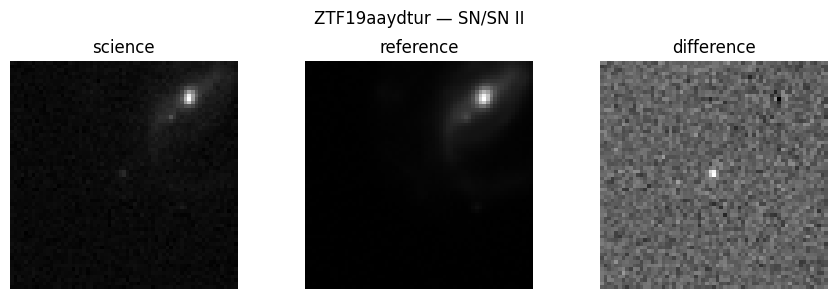

In [11]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt

man = json.loads((cfg.gold / "MANIFEST.json").read_text())
print(json.dumps(man, indent=2)[:1400])

feat = pd.read_parquet(cfg.gold / "gold_features.parquet")
lab  = pd.read_parquet(cfg.gold / "gold_labels.parquet")
meta = pd.read_parquet(cfg.gold / "gold_metadata.parquet")
spl  = pd.read_parquet(cfg.gold / "gold_splits.parquet")
npz  = np.load(cfg.gold / "gold_stamps.npz", allow_pickle=True)
X_img, oids = npz["stamps"], npz["oids"]

print("\nfeatures:", feat.shape, "| stamps:", X_img.shape)
print("\nsplit x coarse:")
print(lab.merge(spl, on="oid").groupby(["split", "coarse"]).size().unstack(fill_value=0))

# the three cutouts for one object
i = 0
oid0 = str(oids[i]); row = lab.set_index("oid").loc[oid0]
chans = ["science", "reference", "difference"]
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for j, c in enumerate(chans):
    ax[j].imshow(X_img[i, j], origin="lower", cmap="gray"); ax[j].set_title(c); ax[j].axis("off")
fig.suptitle(f"{oid0} — {row['coarse']}/{row['fine']}")
plt.tight_layout(); plt.show()